# Import Library

In [1]:
!pip install sastrawi
!pip install nltk
!pip install gensim
!pip install tensorflow
!pip install keras
!pip install vaderSentiment
!pip install num2words
 #menggunakan mpstemmer untuk mempercepat hasil stemming
!pip install python-Levenshtein
!pip install --upgrade git+https://github.com/ariaghora/mpstemmer.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 4.8 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=a2e0b67b8d5c8ba2f7b8a3cd14f1088ab32c215ea1eb43a0434c41831ed5fd16
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.3 MB/s eta 0:00:00
  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-hm2bguoq
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-hm2bguoq
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 2

In [2]:
import pandas as pd # Pustaka untuk membuat dataframe
import numpy as np # pustaka untuk pengolahan angka
import matplotlib.pyplot as plt # Pustaka untuk visualisasi
import seaborn as sns # Pustaka untuk visualisasi
import re # Pustaka regex
import string #Pustaka untuk manipulasi string
import nltk  # Import pustaka NLTK (Natural Language Toolkit).
from nltk.tokenize import word_tokenize # Tokenisasi teks
from nltk.corpus import stopwords # Daftar kata-kata berhenti dalam teks
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia
from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer # Labelling menggunakan VADER
from num2words import num2words # Pustaka untuk merubah angka menjadi kata

In [3]:
# Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata yang tidak memiliki makna (stopwords)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Data Loading

In [17]:
# Memuat dataset
df = pd.read_csv("https://raw.githubusercontent.com/rfahreza/Analisis-Sentimen-Google-Calendar/refs/heads/main/google_calendar_review.csv")
df

,content,score
0,tampilan bulan dengan kalender alternatif dibu...,4
1,tolong developer perbaiki tampilan menu bulan ...,2
2,"Suka banget app ini, praktis dan lengkap, hany...",5
3,Suka banget sama aplikasinya. Kalo mau buat ja...,5
4,masa update terus sihh tiap seminggu sekali up...,1
...,...,...
9995,Ok,5
9996,Ms.,1
9997,Kikuk 🙂,5
9998,"it*s Ok,,,,,,,,",5


In [18]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  10000 non-null  object
 1   score    10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


Dataset ini memuat **10.000** ulasan dari pengguna aplikasi **Google Calendar** yang diambil dari Playstore. Fokus utama dari dataset ini adalah untuk melakukan analisis sentimen terhadap aplikasi, berdasarkan teks ulasan (content) dan nilai rating (score) yang diberikan oleh pengguna.

# Data Cleaning

Karena sudah kolom dataset sudah ditentukan sebelumnya, maka kita dapat langsung menggunakan semua kolom yang ada

In [19]:
# Cek jumlah missing values
print(df.isna().sum(),'\n')
# Cek duplicate values
print('Jumlah duplikasi data : ',df.duplicated().sum())

content    0
score      0
dtype: int64 

Jumlah duplikasi data :  2313


Masih ada data yang terduplikasi, tapi karena untuk melakukan analisis sentimen, saya tidak menghapusnya karena bisa saja yang terduplikasi tersebut merupakan representasi dari pengalaman pengguna.

Opsi lainnya mungkin bisa membandingkan ketika menghapus data duplikat dan yang tidak

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  10000 non-null  object
 1   score    10000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


## Quick EDA

In [28]:
score_counts = df['score'].value_counts().sort_index()
score_counts.head()

,count
score,
1,972
2,328
3,650
4,927
5,7123


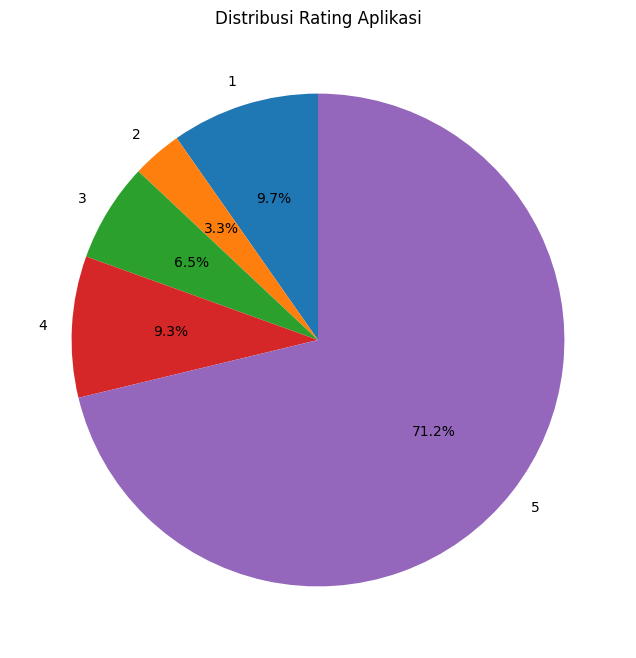

In [29]:
# Membuat pie chart
plt.figure(figsize=(8, 8))
plt.pie(score_counts, labels=score_counts.index, autopct='%1.1f%%', startangle=90)

# Menambahkan judul
plt.title('Distribusi Rating Aplikasi')

# Menampilkan pie chart
plt.show()

# Text Preprocessing

## Casefolding dan Text Cleaning

In [21]:
# Case folding
def casefolding(text):
    text = text.lower()
    return text

# Text Cleaning
def cleaning(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # hapus mention
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)  # hapus hashtag
    text = re.sub(r'http\S+', '', text)         # hapus URL

    # Ubah angka ke teks
    def convert_number_to_words(match):
        number = int(match.group())
        return num2words(number, lang='id')  # Bahasa Indonesia

    text = re.sub(r'\d+', convert_number_to_words, text)
    text = text.replace('\n', ' ')  # hapus baris baru
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = text.strip() # menghapus karakter spasi
    return text

## Tokenisasi dan filter stopword

In [22]:
# Tokenisasi
def tokenizing(text):
    text = word_tokenize(text)
    return text

# Menghapus stopwords
def filtering(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','sih','sii','ku',"di","ga","ya","gaa","loh","kah","dong","woi","woii","woy","kan","deh","yang","yg","emang","memang"])
    filtered = []
    for txt in text:
        if txt.lower() not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

## Normalisasi kata

In [23]:
# Membuat kamus kata slang
slang_dict = {
    "ga": "tidak",
    "gk": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "udh": "sudah",
    "sdh": "sudah",
    "bgt": "banget",
    "dr": "dari",
    "aja": "saja",
    "tp": "tapi",
    "jd": "jadi",
    "blm": "belum",
    "yg": "yang",
    "sm": "sama",
    "trs": "terus",
    "krn": "karena",
    "lemot": "lambat",
    "lelet": "lambat",
    "crash": "berhenti tiba-tiba",
    "ngelag": "lambat",
    "error": "kesalahan",
    "notifikasi": "pengingat",
    "notif": "pengingat",
    "remind": "ingatkan",
    "reminder": "pengingat",
    "event": "acara",
    "meet": "pertemuan",
    "meeting": "rapat",
    "jadwalin": "menjadwalkan",
    "kelupaan": "lupa",
    "multitask": "melakukan banyak hal",
    "lag": "lambat",
    "hang": "berhenti",
    "update": "pembaruan",
    "sinkron": "sinkronisasi",
    "sync": "sinkronisasi",
    "akun": "akun pengguna",
    "login": "masuk",
    "logout": "keluar",
    "signup": "daftar",
    "crashnya": "berhenti tiba-tiba",
    "responnya": "respons aplikasi",
    "ngingetin": "mengingatkan",
    "nunjukin": "menunjukkan",
    "hapusin": "menghapus",
    "tambahin": "menambahkan",
    "ngatur": "mengatur",
    "bikin jadwal": "menjadwalkan",
    "bikin acara": "membuat acara",
    "delay": "terlambat",
    "schedule": "jadwal",
    "nginget": "mengingat",
    "waktu solat": "jadwal ibadah",
    "pengingatnya": "fitur pengingat",
    "remindernya": "fitur pengingat",
    "bug": "masalah aplikasi",
    "buggy": "bermasalah",
    "hilang": "tidak tersedia",
    "ilang": "tidak tersedia",
    "ngebug": "bermasalah",
    "laggy": "lambat",
    "ngebug": "bermasalah",
    "nggak bisa sync": "tidak bisa sinkronisasi",
    "ga bisa dibuka": "tidak bisa dibuka",
    "gagal login": "tidak bisa masuk",
    "ngaco": "tidak berjalan dengan baik",
    "nggak jalan": "tidak berfungsi"
}
# fungsi untuk normalisasi kata slang
def normalize_slang(tokens):
    return [slang_dict.get(word.lower(), word) for word in tokens]

## Stemming dan menggabungkan text

In [27]:
from mpstemmer import MPStemmer #impor pustaka mpstemmer
from functools import lru_cache #menggunakan metode cache supaya kata yang sudah distem tidak perlu diulang

# fungsi MPStemmer menggunakan cache sebesar 10.000 kata
stemmer = MPStemmer()
@lru_cache(maxsize=10000)
def cached_stem(word):
    return stemmer.stem(word)

def stemmingText(text):
    stemmed_words = [cached_stem(word) for word in text]
    return stemmed_words

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

## Menjalankan pipeline text preprocessing

In [30]:
# Mengubah huruf dalam teks menjadi huruf kecil
df['clean_content'] = df['content'].apply(casefolding)

In [31]:
# Membersihkan teks
df['clean_content'] = df['clean_content'].apply(cleaning)

In [32]:
# Memecah teks menjadi token (list kata)
df['clean_content'] = df['clean_content'].apply(tokenizing)

In [33]:
# Menghapus stopwords
df['clean_content'] = df['clean_content'].apply(filtering)

In [34]:
# Mengganti kata-kata slang dengan kata-kata standar
df['clean_content'] = df['clean_content'].apply(normalize_slang)

In [35]:
# Melakukan stemming
df['clean_content'] = df['clean_content'].apply(stemmingText)

In [36]:
# Menggabungkan token-token menjadi kalimat
df['clean_content'] = df['clean_content'].apply(toSentence)

In [37]:
df

,content,score,clean_content
0,tampilan bulan dengan kalender alternatif dibu...,4,tampil kalender alternatif rapi susun kanan ki...
1,tolong developer perbaiki tampilan menu bulan ...,2,tolong developer baik tampil menu bikin simple...
2,"Suka banget app ini, praktis dan lengkap, hany...",5,suka banget app praktis lengkap pecinta aesthe...
3,Suka banget sama aplikasinya. Kalo mau buat ja...,5,suka banget aplikasi kalau jadwal sampe timeli...
4,masa update terus sihh tiap seminggu sekali up...,1,baru sihh minggu baru teruss saja tidak baru a...
...,...,...,...
9995,Ok,5,ok
9996,Ms.,1,ms
9997,Kikuk 🙂,5,kikuk
9998,"it*s Ok,,,,,,,,",5,ok


Terlihat bahwa kolom **clean_content** sudah dalam huruf kecil seluruhnya, tanpa menyertakan angka, dan kata-kata tidak penting (stopword) juga telah dihapus setelah melalui **Text Processing**

# Labelling

## Polaritas text berdasarkan VADER

In [38]:
analyzer = SentimentIntensityAnalyzer()

# Fungsi untuk memberi label dari skor VADER
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positif'
    elif score <= -0.05:
        return 'negatif'
    else:
        return 'netral'

# Terapkan ke kolom teks bersih
df['vader_sentiment'] = df['clean_content'].apply(get_vader_sentiment)
# menampilkan distribusi
print(df['vader_sentiment'].value_counts())

vader_sentiment
netral     8943
positif     979
negatif      78
Name: count, dtype: int64


Hasil ulasan di dominasi oleh netral, positif, dan beberapa ulasan negatif

Meskipun analisis VADER menunjukkan dominasi sentimen netral, rating tinggi sebesar 4.7 di Playstore mengindikasikan bahwa mayoritas pengguna sebenarnya merasa puas. Hal ini bisa menunjukkan adanya keterbatasan dalam metode analisis sentimen otomatis terhadap teks ulasan yang bersifat informal atau kontekstual.



In [39]:
# distribusi lebih detail
df[['content', 'vader_sentiment']].head()

,content,vader_sentiment
0,tampilan bulan dengan kalender alternatif dibu...,netral
1,tolong developer perbaiki tampilan menu bulan ...,netral
2,"Suka banget app ini, praktis dan lengkap, hany...",netral
3,Suka banget sama aplikasinya. Kalo mau buat ja...,netral
4,masa update terus sihh tiap seminggu sekali up...,netral


## Visualisasi WordCloud

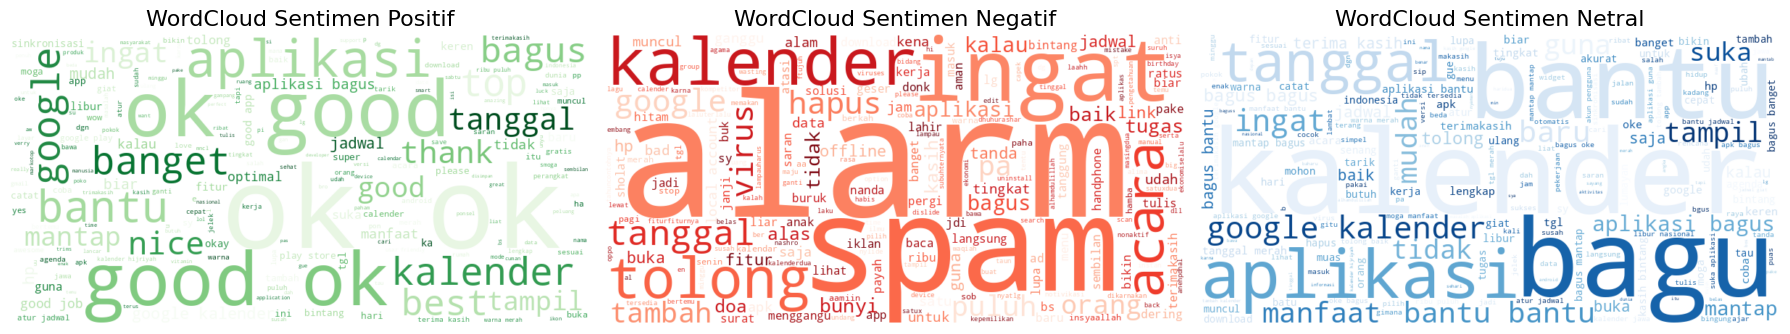

In [40]:
# Gabungkan teks berdasarkan label sentimen
sentiment_texts = {
    sentiment: ' '.join(df[df['vader_sentiment'] == sentiment]['clean_content'])
    for sentiment in ['positif', 'negatif', 'netral']
}

# Membuat wordcloud dengan grid (1x3)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 baris, 3 kolom
colors = {'positif': 'Greens', 'negatif': 'Reds', 'netral': 'Blues'}

for ax, (sentiment, text) in zip(axes, sentiment_texts.items()):
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colors[sentiment],
        max_words=200
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'WordCloud Sentimen {sentiment.capitalize()}', fontsize=16)
    ax.axis('off')

plt.tight_layout()
plt.show()

1. WordCloud Sentimen Positif

**Kata-kata dominan**:  
`good`, `ok`, `aplikasi`, `kalender`, `bantu`, `top`, `bagus`, `mantap`, `nice`, `thank`

**Interpretasi**:  
Ulasan dengan sentimen positif umumnya berisi apresiasi terhadap fungsi aplikasi yang membantu pengguna dalam mengelola jadwal dan pengingat. Kata-kata seperti *"bantu"*, *"mantap"*, dan *"aplikasi bagus"* menandakan kepuasan pengguna. Ucapan seperti *"thank"* dan *"nice"* juga muncul, yang menunjukkan adanya pengalaman positif secara keseluruhan.

Contoh konteks penggunaan:
> "Aplikasi ini sangat membantu mengingatkan jadwal harian saya, mantap!"

---

2. WordCloud Sentimen Negatif

**Kata-kata dominan**:  
`alarm`, `spam`, `kalender`, `hapus`, `virus`, `tolong`, `tidak`, `buny`

**Interpretasi**:  
Sentimen negatif banyak mengeluhkan fitur *alarm* yang dianggap mengganggu (*spam*) dan kesulitan dalam menghapus atau menonaktifkan fitur tertentu. Beberapa pengguna juga menyuarakan kekhawatiran terhadap keamanan (*virus*) serta pengalaman tidak nyaman dengan tampilan atau bug dalam aplikasi.

Contoh konteks penggunaan:
> "Alarmnya bunyi terus seperti spam, tolong perbaiki."

---

3. WordCloud Sentimen Netral

**Kata-kata dominan**:  
`bagus`, `aplikasi`, `kalender`, `ingat`, `tanggal`, `bantu`, `tampil`, `suka`

**Interpretasi**:  
Ulasan netral cenderung bersifat informatif atau menyampaikan saran. Pengguna menyebut fitur seperti *kalender* dan *pengingat* tanpa memberikan pujian atau kritik yang kuat. Kata seperti *"bagus"* atau *"suka"* bisa digunakan dalam konteks deskriptif, bukan emosional.

Contoh konteks penggunaan:
> "Kalender tampilannya cukup bagus, tapi mungkin bisa lebih simpel."

---


# Feature Extraction + Modelling

## Skema 1 : Decision Tree + CountVectorizer,    Pembagian Data: 80/20

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Ekstraksi fitur menggunakan CountVectorizer
vectorizer = CountVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_content'])

# Label target
y = df['vader_sentiment']

# Membagi data latih dan uji (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Membuat dan melatih model Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# Evaluasi
print("Decision Tree + CountVectorizer")
print(classification_report(y_test, y_pred_dt))
print("Akurasi:", accuracy_score(y_test, y_pred_dt))


Decision Tree + CountVectorizer
              precision    recall  f1-score   support

     negatif       0.92      0.73      0.81        15
      netral       0.99      1.00      0.99      1789
     positif       0.99      0.93      0.96       196

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.92      2000
weighted avg       0.99      0.99      0.99      2000

Akurasi: 0.9905


Model ini sangat baik secara umum, terlihat dari akurasi tinggi (99.05%).

Namun, model kurang optimal dalam mendeteksi review negatif, dengan recall hanya 0.73, dan juga sedikit menurun pada review positif (recall 0.93). Ini menunjukkan bahwa model masih sering gagal mengenali data minoritas.

Hal ini kemungkinan besar disebabkan oleh ketidakseimbangan distribusi data antar kelas:
* Kelas netral sangat dominan (1789 dari 2000 data).
* Kelas negatif hanya 15 data, dan positif hanya 196 data.

Agar model lebih adil dan akurat dalam mendeteksi semua kelas, kita bisa melakukan
1. Oversampling Kelas Minoritas (misal: teknik SMOTE)
2. Gunakan Class Weight Balance

## Skema 2 : Random Forest,    Ekstraksi Fitur: Word2Vec,    Pembagian Data: 80/20

In [49]:
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Training Word2Vec dari token
df['token'] = df['clean_content'].apply(lambda x: x.split())
tokenized = df['token']
w2v_model = Word2Vec(sentences=tokenized, vector_size=100, window=5, min_count=2, workers=4)

# Fungsi rata-rata Word2Vec
def vectorize(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

# Vektorisasi
X_w2v = np.array([vectorize(tokens, w2v_model) for tokens in tokenized])

# Label target
y = df['vader_sentiment']

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
print("Random Forest + Word2Vec")
print(classification_report(y_test, y_pred_rf))
print("Akurasi:", accuracy_score(y_test, y_pred_rf))

Random Forest + Word2Vec
              precision    recall  f1-score   support

     negatif       0.00      0.00      0.00        15
      netral       0.96      1.00      0.98      1789
     positif       1.00      0.65      0.79       196

    accuracy                           0.96      2000
   macro avg       0.65      0.55      0.59      2000
weighted avg       0.95      0.96      0.95      2000

Akurasi: 0.958


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Model Random Forest + Word2Vec menunjukkan akurasi yang secara angka terlihat tinggi, yaitu 95.75%. Namun, performa model ini sebenarnya sangat tidak seimbang antar kelas, khususnya dalam mendeteksi review negatif dan positif.

Pada kelas negatif, model gagal dalam melakukan prediksi yang benar, terbukti dari nilai precision, recall, dan f1-score yang semuanya nol (0.00). Ini berarti, dari seluruh data negatif yang ada, tidak satu pun berhasil diklasifikasikan dengan benar oleh model. Sementara itu, pada kelas positif, meskipun precision masih tinggi (1.00), nilai recall hanya mencapai 0.64, yang menunjukkan bahwa 36% data positif tidak berhasil dikenali dengan benar. Ini berdampak pada turunnya nilai f1-score positif menjadi hanya 0.78.

Sebaliknya, performa model sangat baik pada kelas netral dengan precision dan recall mencapai 0.95 dan 1.00. Hal ini tidak mengherankan, mengingat data netral mendominasi jumlah dataset (1789 dari 2000 data).

Meskipun akurasi model tinggi, model cenderung hanya menebak kelas netral, sehingga akurasi menjadi metrik yang menyesatkan dalam konteks data yang tidak seimbang. Kualitas prediksi untuk kelas minoritas (negatif dan positif) masih sangat rendah dan belum dapat diandalkan.

Untuk memperbaiki kondisi ini, disarankan agar dilakukan penyeimbangan data, seperti menggunakan teknik oversampling seperti SMOTE, atau menerapkan pengaturan class weight pada model Random Forest. Alternatif lainnya, mempertimbangkan penggunaan model yang lebih tahan terhadap ketidakseimbangan data seperti XGBoost atau SVM dengan class weight juga bisa menjadi solusi yang tepat.

## Skema 3 : SVM,    Ekstraksi Fitur: TF-IDF,    Pembagian Data: 80/20

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Ekstraksi fitur TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_content'])

# Label target
y = df['vader_sentiment']

# Pembagian data 80/20
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Model SVM
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Evaluasi
print("SVM + TF-IDF")
print(classification_report(y_test, y_pred_svm))
print("Akurasi:", accuracy_score(y_test, y_pred_svm))

SVM + TF-IDF
              precision    recall  f1-score   support

     negatif       1.00      0.53      0.70        15
      netral       0.98      1.00      0.99      1789
     positif       1.00      0.86      0.92       196

    accuracy                           0.98      2000
   macro avg       0.99      0.80      0.87      2000
weighted avg       0.98      0.98      0.98      2000

Akurasi: 0.9825


Model SVM + TF-IDF memberikan performa yang kuat dan stabil, terutama dalam menangani kelas mayoritas dan positif. Namun, kelas negatif masih underperform di sisi recall, sehingga perlu perhatian khusus jika kelas negatif bersifat kritikal (misalnya untuk mengidentifikasi keluhan pelanggan atau isu penting).


## Conclusion

Berdasarkan 3 Skema diatas mendapat perolehan score accuracy yaitu :
* Decision Tree + CountVec + 80/20: Akurasi: 0.9905
* Random Forest + Word2Vec + 70/30: Akurasi : 0.9575
* SVM + TF-IDF + 80/20 : Akurasi : 0.9825

Secara keseluruhan, model Decision Tree + CountVec + 80/20 merupakan yang terbaik karena akurasi yang tinggi, F1-score yang bagus di setiap kelas, meskipun recall kelas negatif belum sempurna, tapi masih lebih bagus dari yang lain.

Akan tetapi, Model SVM + TF-IDF + 80/20 memiliki peforma yang stabil, kuat di kelas mayoritas & positif, meskipun recall negatif masih rendahn tapi bisa jadi lebih baik kalau kamu tambahkan class_weight='balanced'.

Tapi untuk saat ini saya menggunakan Decision Tree + CountVec + 80/20 dahulu.

# Save models

In [79]:
import pickle

# Simpan vectorizer dan model Decision Tree dalam satu file
with open('dt_countvec_model.pkl', 'wb') as f:
    pickle.dump((vectorizer, dt_model), f)


# Inference

In [82]:
# Load vectorizer dan model Decision Tree
with open('dt_countvec_model.pkl', 'rb') as f:
    vectorizer_loaded, dt_model_loaded = pickle.load(f)

# Contoh kalimat baru untuk diprediksi
text_baru = [
    "fitur aplikasi sangat keren",     # positif
    "banyak error dan aplikasi tidak responsif",  # negatif
    "menu tampilannya cukup standar",      # netral
]

# Transformasi teks ke bentuk vektor (dengan vectorizer hasil load)
X_new = vectorizer_loaded.transform(text_baru)

# Prediksi menggunakan model Decision Tree
prediksi = dt_model_loaded.predict(X_new)

# Tampilkan hasil prediksi
for kalimat, label in zip(text_baru, prediksi):
    print(f"{kalimat} -> {label}")


fitur aplikasi sangat keren -> netral
banyak error dan aplikasi tidak responsif -> netral
menu tampilannya cukup standar -> netral


 Kemungkinan model mengalami bias ke kelas mayoritas bisa jadi dikarenakan Dataset latih kemungkinan tidak seimbang (kelas netral lebih dominan) dan Decision Tree tidak belajar cukup dari fitur pembeda antar kelas. Ataupun mungkin dikarenakan preprocessing kurang optimal, misalnya kata-kata penting tidak tertangkap karena tidak distem/stemming atau tidak ada stopwords removal. Kemungkinan lain juga dapat karena vectorizer belum mencakup kata-kata baru seperti “keren” jika tidak pernah muncul di data latih.

 Selanjutnya mungkin bisa mencoba model lain yang memiliki akurasi yang tinggi dan berpotensi tidak overfitting